#### 데이터 불러오기

In [11]:
import pandas as pd

file_path = 'C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv'
df = pd.read_csv(file_path)

print(f"데이터 크기: {df.shape}")

데이터 크기: (490705, 16)


#### 수치형 변수 분포 시각화

In [13]:
print(df.columns.tolist())

['id', 'product_id', 'created_at', 'sold_at', 'cost', 'product_category', 'product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku', 'product_distribution_center_id', 'created_year', 'created_month', 'created_day', 'created_weekday']


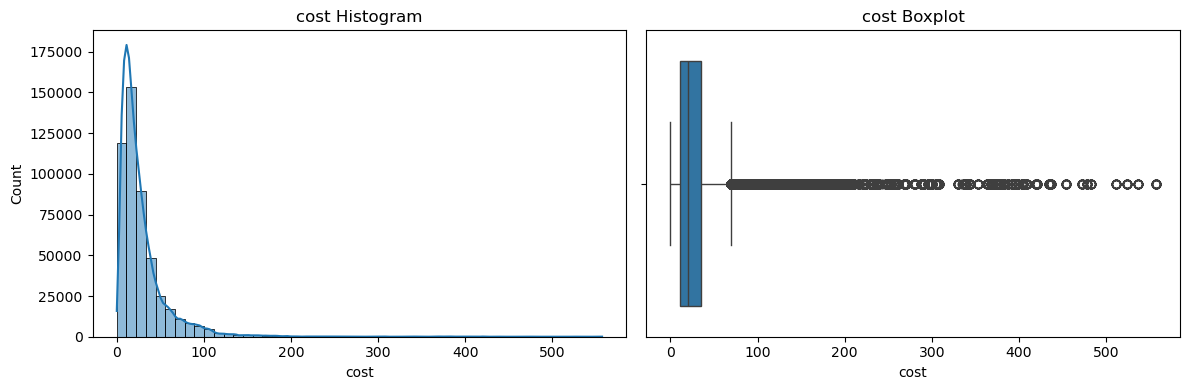

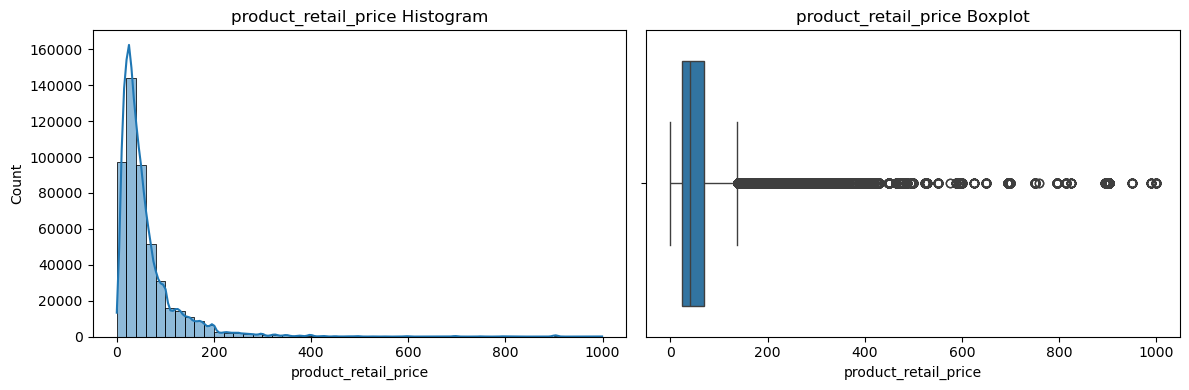

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 불러오기
file_path = 'C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv'
df = pd.read_csv(file_path)

# 시각화할 수치형 컬럼
num_cols = ['cost', 'product_retail_price']

# 분포 시각화
for col in num_cols:
    plt.figure(figsize=(12, 4))
    
    # 히스토그램
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'{col} Histogram')
    
    # 박스플롯
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    
    plt.tight_layout()
    plt.show()

### 가격대별로 매출에 기여하는 정도

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\143062495.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_count = df.groupby('price_range')['product_id'].nunique().reset_index(name='상품 수')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\143062495.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_count = df.groupby('price_range').size().reset_index(name='판매량')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\143062495.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

  price_range  상품 수     판매량         매출 합계   매출 비중(%)
0        0-20  6005   99814  1.375207e+06   4.704616
1       20-40  8935  151235  4.581444e+06  15.673224
2       40-60  5389   92155  4.660934e+06  15.945164
3       60-80  2916   49268  3.482497e+06  11.913703
4         80+  5801   98233  1.513094e+07  51.763293


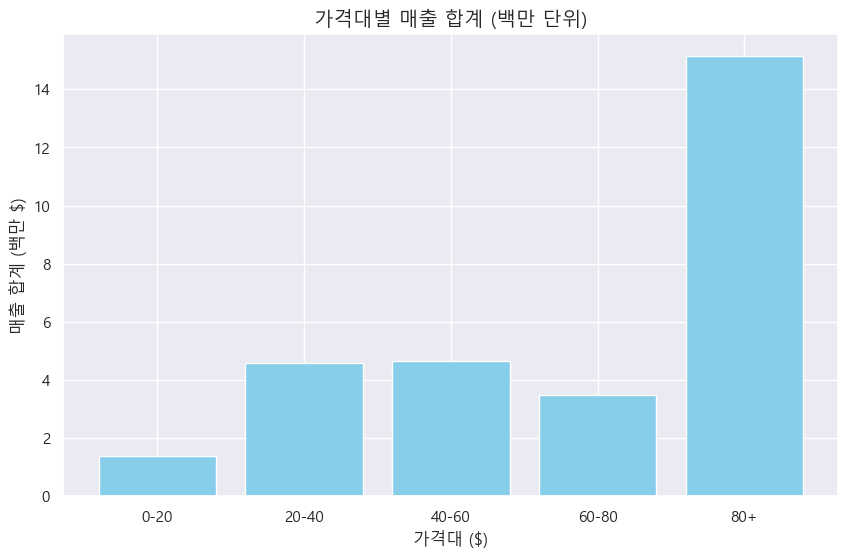

In [171]:
# 예) 가격대 구간 설정
bins = [0, 20, 40, 60, 80, df['product_retail_price'].max()]
labels = ['0-20', '20-40', '40-60', '60-80', '80+']

# 가격대 구간 컬럼 추가
df['price_range'] = pd.cut(df['product_retail_price'], bins=bins, labels=labels, include_lowest=True)

# 가격대별 상품 수 (unique product_id 기준)
product_count = df.groupby('price_range')['product_id'].nunique().reset_index(name='상품 수')

# 가격대별 판매량 (판매 건수, row 수 기준)
sales_count = df.groupby('price_range').size().reset_index(name='판매량')

# 가격대별 매출 합계
df['total_price'] = df['product_retail_price']  # quantity가 없으므로 단가 기준 매출로 가정
sales_sum = df.groupby('price_range')['total_price'].sum().reset_index(name='매출 합계')

# 가격대별 매출 비중 계산
total_sales = sales_sum['매출 합계'].sum()
sales_sum['매출 비중(%)'] = sales_sum['매출 합계'] / total_sales * 100

# 결과 병합
result = product_count.merge(sales_count, on='price_range').merge(sales_sum, on='price_range')

print(result)

# 시각화 (매출 합계)
plt.figure(figsize=(10, 6))
plt.bar(result['price_range'], result['매출 합계'] / 1e6, color='skyblue')
plt.title('가격대별 매출 합계 (백만 단위)', fontsize=14)
plt.xlabel('가격대 ($)', fontsize=12)
plt.ylabel('매출 합계 (백만 $)', fontsize=12)
plt.show()

#### 카테고리 별 평균 가격대 비교

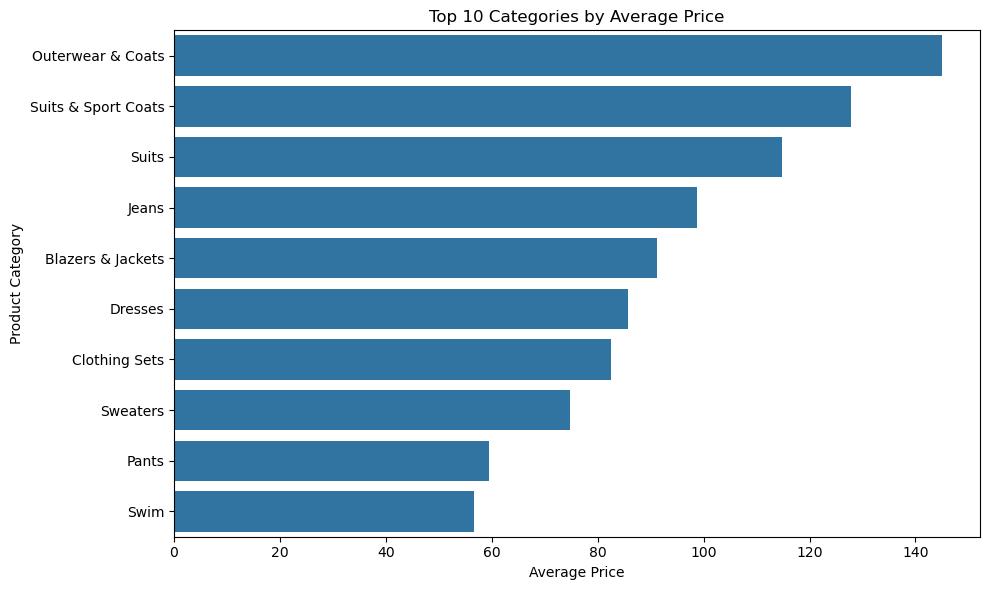

In [22]:
# 1. 카테고리 기준 집계
category_summary = df.groupby('product_category').agg(
    product_count=('product_id', 'nunique'),
    avg_price=('product_retail_price', 'mean'),
    min_price=('product_retail_price', 'min'),
    max_price=('product_retail_price', 'max')
).reset_index().sort_values(by='avg_price', ascending=False)

# 2. 시각화: 평균 가격 상위 10개 카테고리
plt.figure(figsize=(10, 6))
sns.barplot(data=category_summary.head(10), x='avg_price', y='product_category')
plt.title('Top 10 Categories by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

#### 성별 평균 가격대 비교

  product_department  product_count  avg_price  min_price  max_price
0                Men          13117  63.204436       1.50      999.0
1              Women          15929  55.942510       0.02      903.0


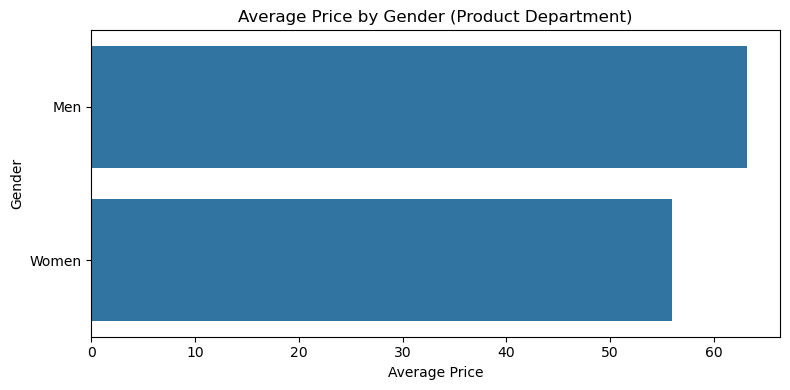

In [29]:
# 1. 성별 기준 집계 요약
gender_summary = df.groupby('product_department').agg(
    product_count=('product_id', 'nunique'),
    avg_price=('product_retail_price', 'mean'),
    min_price=('product_retail_price', 'min'),
    max_price=('product_retail_price', 'max')
).reset_index().sort_values(by='avg_price', ascending=False)

print(gender_summary)

# 2. 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(data=gender_summary, x='avg_price', y='product_department')
plt.title('Average Price by Gender (Product Department)')
plt.xlabel('Average Price')
plt.ylabel('Gender')
plt.tight_layout()
plt.show()

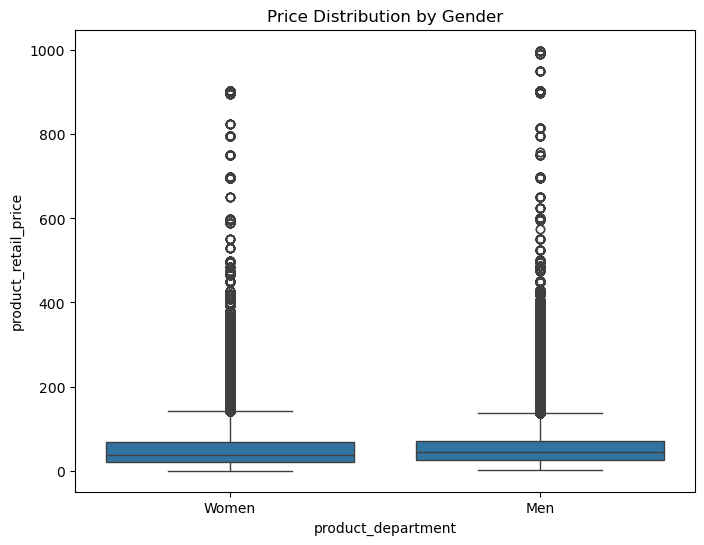

In [31]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='product_department', y='product_retail_price')
plt.title('Price Distribution by Gender')
plt.show()

#### 브랜드별로 성별 가격 차이 분석

In [39]:
# 1. 브랜드 & 성별 그룹별 평균 가격 요약
brand_gender_price = df.groupby(['product_brand', 'product_department']).agg(
    avg_price=('product_retail_price', 'mean'),
    product_count=('product_id', 'nunique')
).reset_index()

# 2. 피벗 형태로 성별별 가격 나란히 보기
brand_price_pivot = brand_gender_price.pivot(index='product_brand', columns='product_department', values='avg_price')

# 3. 남자 평균 가격 > 여자 평균 가격 차이 큰 브랜드 Top 10
brand_price_pivot['price_diff'] = brand_price_pivot.get('Men', 0) - brand_price_pivot.get('Women', 0)
brand_price_pivot_sorted = brand_price_pivot.sort_values(by='price_diff', ascending=False)

print(brand_price_pivot_sorted.head(10))  # 가격 차이 큰 브랜드 Top 10

product_department            Men       Women  price_diff
product_brand                                            
The North Face         528.273392  308.805795  219.467597
RAB                    325.000000  162.918747  162.081253
D&G Dolce & Gabbana    239.949997   84.927078  155.022919
GUESS by Marciano      328.000000  173.641026  154.358974
Zoot                   205.039109   58.902727  146.136382
Filson                 158.335714   32.000000  126.335714
Jones New York         216.782150   90.570248  126.211902
Stitch's               137.699997   25.000000  112.699997
Stormy Kromer          161.297794   48.930000  112.367794
Overland Sheepskin Co  382.906250  272.500000  110.406250


#### 남성 상품 중 고가 제품 파악

In [41]:
# 남자 상품만 필터링
male_products = df[df['product_department'] == 'Men']

# 소매 가격 상위 10개 고가 상품
top_male_high_price = male_products.sort_values(by='product_retail_price', ascending=False).head(10)

# 주요 컬럼만 보기
print(top_male_high_price[['product_name', 'product_brand', 'product_retail_price']])

                           product_name     product_brand  \
210911                            Darla  Alpha Industries   
210914                            Darla  Alpha Industries   
210904                            Darla  Alpha Industries   
210905                            Darla  Alpha Industries   
270195  Alpha Industries Rip Stop Short  Alpha Industries   
270194  Alpha Industries Rip Stop Short  Alpha Industries   
270193  Alpha Industries Rip Stop Short  Alpha Industries   
270192  Alpha Industries Rip Stop Short  Alpha Industries   
270191  Alpha Industries Rip Stop Short  Alpha Industries   
270190  Alpha Industries Rip Stop Short  Alpha Industries   

        product_retail_price  
210911                 999.0  
210914                 999.0  
210904                 999.0  
210905                 999.0  
270195                 999.0  
270194                 999.0  
270193                 999.0  
270192                 999.0  
270191                 999.0  
270190            

#### 여성 상품 중 고가 제품 파악

In [44]:
# 여자 상품만 필터링
male_products = df[df['product_department'] == 'Women']

# 소매 가격 상위 10개 고가 상품
top_male_high_price = male_products.sort_values(by='product_retail_price', ascending=False).head(10)

# 주요 컬럼만 보기
print(top_male_high_price[['product_name', 'product_brand', 'product_retail_price']])

                                             product_name   product_brand  \
223064      The North Face Denali Down Womens Jacket 2013  The North Face   
46309       The North Face Denali Down Womens Jacket 2013  The North Face   
41451   NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outst...            Nike   
41452   NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outst...            Nike   
46304       The North Face Denali Down Womens Jacket 2013  The North Face   
46305       The North Face Denali Down Womens Jacket 2013  The North Face   
46306       The North Face Denali Down Womens Jacket 2013  The North Face   
46307       The North Face Denali Down Womens Jacket 2013  The North Face   
46308       The North Face Denali Down Womens Jacket 2013  The North Face   
46310       The North Face Denali Down Womens Jacket 2013  The North Face   

        product_retail_price  
223064                 903.0  
46309                  903.0  
41451                  903.0  
41452                  903.0

### 요일별매출

In [60]:
weekday_summary = df.groupby('created_weekday').agg(
    product_count=('product_id', 'count'),
    avg_price=('product_retail_price', 'mean'),
    total_price=('product_retail_price', 'sum')  # 판매 건수 * 개별가격의 합
).reset_index()

# 요일 순서 명확하게 지정
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# created_weekday를 범주형으로 지정하여 요일 순서 강제
weekday_summary['created_weekday'] = pd.Categorical(weekday_summary['created_weekday'],
                                                    categories=weekday_order,
                                                    ordered=True)

# 정렬
weekday_summary = weekday_summary.sort_values('created_weekday')

print(weekday_summary)

  created_weekday  product_count  avg_price   total_price
1          Monday          69401  59.539256  4.132084e+06
5         Tuesday          69396  59.318675  4.116479e+06
6       Wednesday          69420  59.430125  4.125639e+06
4        Thursday          69540  59.351945  4.127334e+06
0          Friday          69628  59.459126  4.140020e+06
2        Saturday          69402  60.113003  4.171963e+06
3          Sunday          69513  59.697529  4.149754e+06


In [62]:
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥
else:
    plt.rc('font', family='NanumGothic')    # 리눅스/colab 등

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\1818614757.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_summary, x='created_weekday', y='total_sales_million', palette='viridis')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\1818614757.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


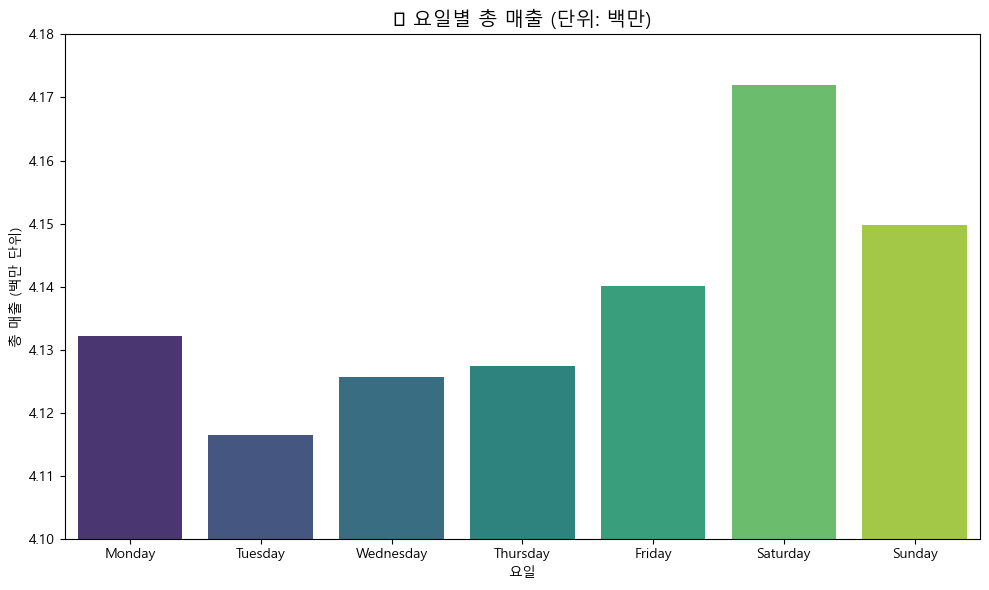

In [64]:
# 백만 단위로 변환
weekday_summary['total_sales_million'] = weekday_summary['total_price'] / 1_000_000

plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_summary, x='created_weekday', y='total_sales_million', palette='viridis')


plt.title('📊 요일별 총 매출 (단위: 백만)', fontsize=14)
plt.ylabel('총 매출 (백만 단위)')
plt.xlabel('요일')
plt.ylim(4.10, 4.18)  # 차이를 더 잘 보기 위한 축 제한
plt.tight_layout()
plt.show()

- 주말 매출이 확실히 높음 -> 주말에 소비활동 증가
- 금요일도 높음 -> 주말 대비 소비 준비 가능성
- 화요일이 가장 낮음 -> 주초 소비 정체 현상?
- 수치로만 봤을 때에는 매출 편차가 크지 않지만, 누적 효과를 감안한다면 전략적으로 요일 운영이 가능할 것으로 보임.

### 시간대별?

In [66]:
print(df['created_at'].head())

0    2022-07-02 07:09:20+00:00
1    2023-12-20 03:28:00+00:00
2    2023-06-04 02:53:00+00:00
3    2021-10-16 22:58:52+00:00
4    2021-08-07 16:33:00+00:00
Name: created_at, dtype: object


#### 시간 컬럼 만들기

In [70]:
# datetime 형식 확실히 지정
df['created_at'] = pd.to_datetime(df['created_at'])

# 시간대(0~23시) 추출
df['created_hour'] = df['created_at'].dt.hour

#### 시간대별 매출 / 상품 수 / 평균가 요약

In [72]:
hourly_summary = df.groupby('created_hour').agg(
    product_count=('product_id', 'count'),
    avg_price=('product_retail_price', 'mean'),
    total_price=('product_retail_price', 'sum')
).reset_index()

In [80]:
# 백만 단위 컬럼 추가
hourly_summary['total_price_million'] = (hourly_summary['total_price'] / 1_000_000).round(2)

# 컬럼 순서 재정렬
hourly_summary = hourly_summary[['created_hour', 'product_count', 'avg_price', 'total_price_million']]

# 숫자 테이블 출력
print(hourly_summary.sort_values('created_hour'))

    created_hour  product_count  avg_price  total_price_million
0            0.0          23928  59.493529                 1.42
1            1.0          23764  59.552367                 1.42
2            2.0          23774  59.735304                 1.42
3            3.0          23800  59.807437                 1.42
4            4.0          23697  59.973190                 1.42
5            5.0          23618  59.897302                 1.41
6            6.0          23674  59.273649                 1.40
7            7.0          23738  60.189356                 1.43
8            8.0          23501  59.387113                 1.40
9            9.0          23452  59.868784                 1.40
10          10.0          23610  59.232434                 1.40
11          11.0          23411  59.782141                 1.40
12          12.0          24048  59.562087                 1.43
13          13.0          23734  59.254058                 1.41
14          14.0          23384  59.2809

#### 시각화

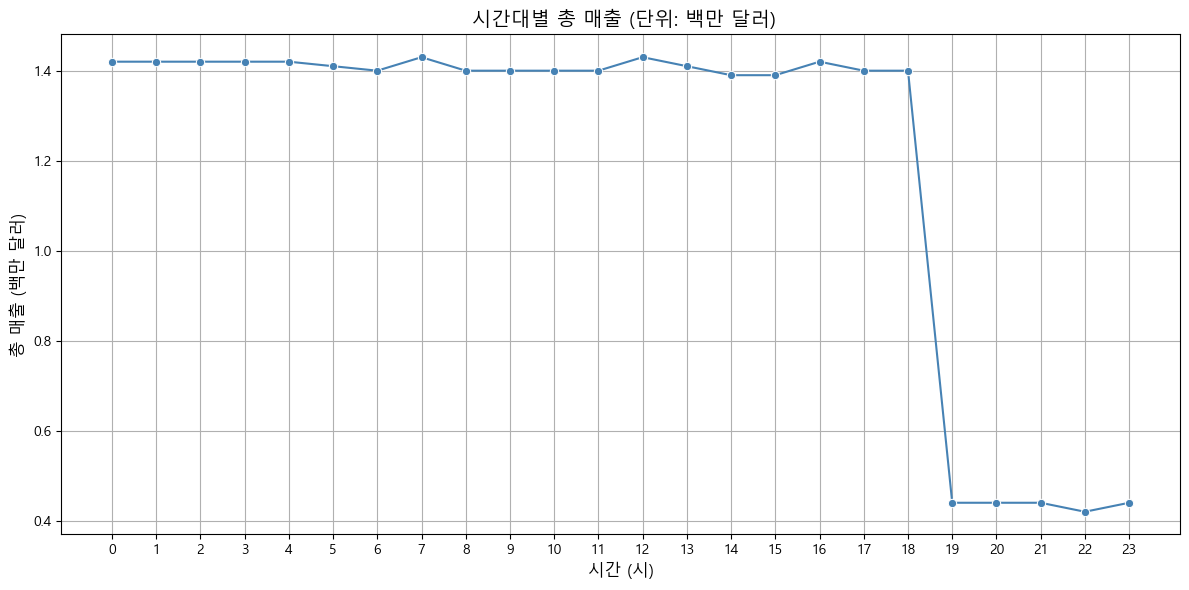

In [88]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_summary, x='created_hour', y='total_price_million', marker='o', color='steelblue')

plt.title(' 시간대별 총 매출 (단위: 백만 달러)', fontsize=14)
plt.xlabel('시간 (시)', fontsize=12)
plt.ylabel('총 매출 (백만 달러)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

### 얻을 수 있는 인사이트
#### 구매 활동은 주로 주간 시간대에 집중되어있다.
- 하루 매출의 대부분이 오전/오후 시간대(0시~18시)에 발생함.
- 야간 시간(18시 이후)에는 매출 급감
- ex) 주요 마케팅, 할인 이벤트 등은 오전~오후 시간대에 하는 것이 효과적으로 보임

#### 야간 시간대는 리소스 최소화 고려 가능
- 19시 이후로는 상대적으로 매출 효율이 낮다고 볼 수 있음
- ex) 시스쳄 트래픽, 운영인력, 광고비 줄임 등으로 리소스 최적화 필요

#### 사용자 행동 기반 마케팅 개선 여지
- 소비자들은 실제로는 이른아침~ 오후에 상품을 검색/구매함
- 반대로 저녁이나 밤에는 쇼핑보다는 탐색/검색만 할 가능성도 있음.
- ex) 이탈율이 높고 매출이 낮은 야간 사용자에게는 뭐 아침쿠폰제공 등 리타게팅 전랴그시도 가능

### 월별 평균 매출액도 구해봐야지

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 월 추출 (숫자형, 1~12)
df['month'] = pd.to_datetime(df['created_at']).dt.month

# 월별 평균 매출 계산 (단위: 백만달러)
monthly_avg = df.groupby('month')['product_retail_price'].sum().reset_index()
monthly_avg['avg_sales_million'] = monthly_avg['product_retail_price'] / df['created_at'].dt.year.nunique() / 1e6
monthly_avg = monthly_avg.rename(columns={'month': '월'})[['월', 'avg_sales_million']]
monthly_avg = monthly_avg.rename(columns={'avg_sales_million': '평균 매출 (백만달러)'})
print(monthly_avg)

       월  평균 매출 (백만달러)
0    1.0      0.351158
1    2.0      0.284094
2    3.0      0.318656
3    4.0      0.313713
4    5.0      0.336169
5    6.0      0.325892
6    7.0      0.348859
7    8.0      0.358806
8    9.0      0.354510
9   10.0      0.380192
10  11.0      0.391061
11  12.0      0.374501


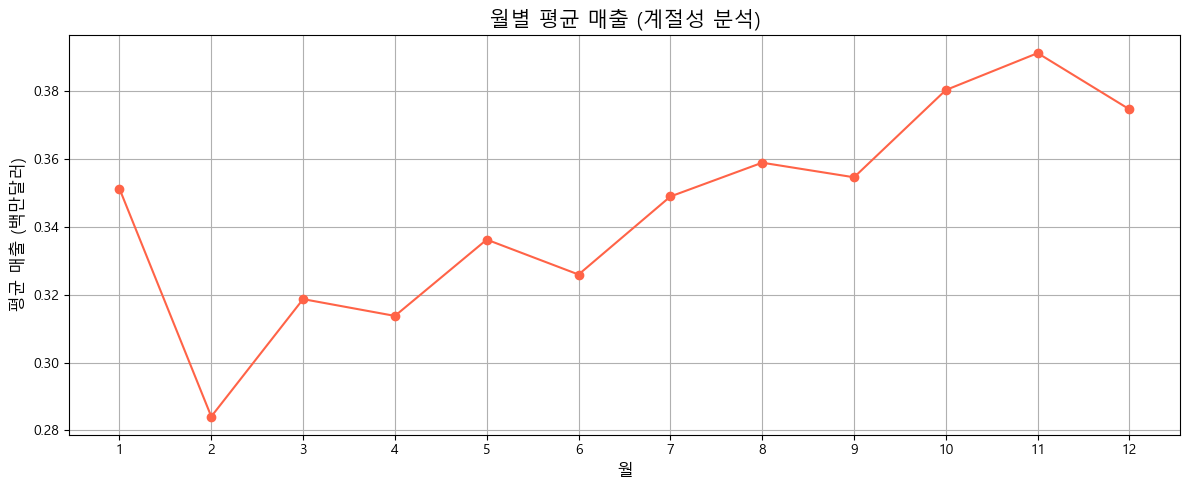

In [97]:
# 그래프
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg['월'], monthly_avg['평균 매출 (백만달러)'], marker='o', linestyle='-', color='tomato')
plt.xticks(range(1, 13))
plt.title('월별 평균 매출 (계절성 분석)', fontsize=15)
plt.xlabel('월', fontsize=12)
plt.ylabel('평균 매출 (백만달러)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

   product_department     월  평균 매출 (백만달러)
0                 Men   1.0      0.188492
1                 Men   2.0      0.150869
2                 Men   3.0      0.167913
3                 Men   4.0      0.167009
4                 Men   5.0      0.178475
5                 Men   6.0      0.170540
6                 Men   7.0      0.183029
7                 Men   8.0      0.189084
8                 Men   9.0      0.188002
9                 Men  10.0      0.202840
10                Men  11.0      0.207904
11                Men  12.0      0.197481


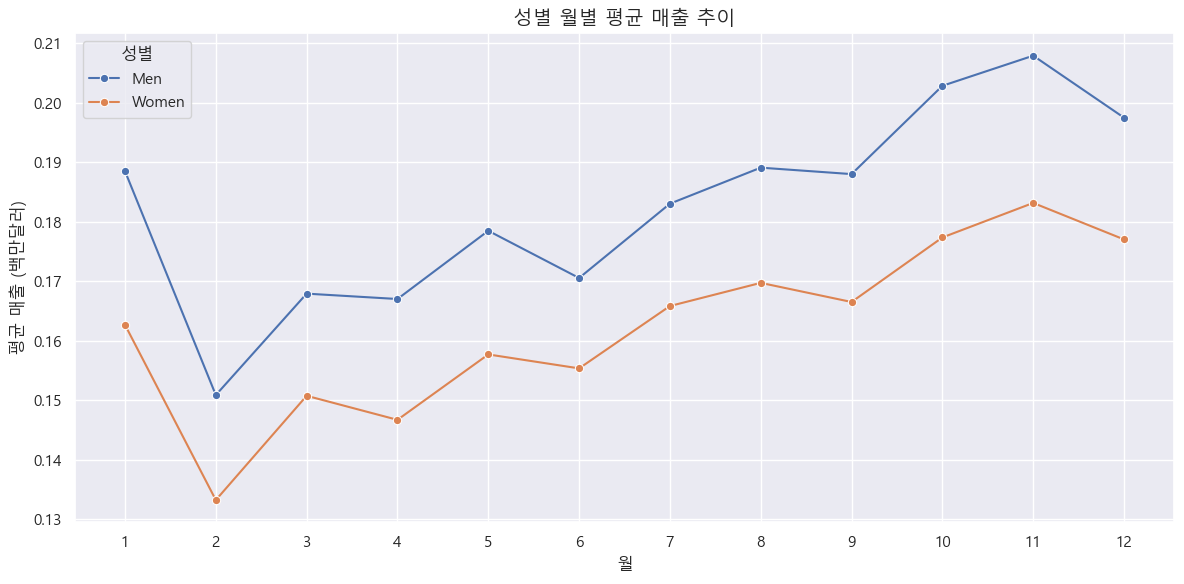

In [127]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# created_at → datetime 형식
df['created_at'] = pd.to_datetime(df['created_at'])

# '월' 컬럼 생성
df['월'] = df['created_at'].dt.month

# 연도 개수 계산
연도수 = df['created_at'].dt.year.nunique()

# 성별 + 월별 매출 합산 → 평균 매출(백만달러) 계산
gender_monthly_sales = (
    df.groupby(['product_department', '월'])['product_retail_price']
    .sum()
    .reset_index()
)

gender_monthly_sales['평균 매출 (백만달러)'] = gender_monthly_sales['product_retail_price'] / 연도수 / 1e6
gender_monthly_sales = gender_monthly_sales.drop(columns='product_retail_price')

# 확인용 출력
print(gender_monthly_sales.head(12))  # 남성/여성 각 월별 평균 매출

# 시각화
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(data=gender_monthly_sales, x='월', y='평균 매출 (백만달러)', hue='product_department', marker='o')

plt.title('성별 월별 평균 매출 추이', fontsize=14)
plt.xlabel('월')
plt.ylabel('평균 매출 (백만달러)')
plt.xticks(range(1, 13))
plt.legend(title='성별')
plt.grid(True)
plt.tight_layout()
plt.show()

### 월 별 인사이트

#### 2월은 확실한 비수기임에 틀림없다.
- 가장 낮은 매출 시점
- 겨울철 소비 위축, 재고 소진기 등으로 예측
- 광고 / 프로모션 강화 추천 시기
#### 11월은 절정의 성수기이다.
- 가장 높은 매출
- 블랙프라이데이, 연말 쇼핑 등등
- 재고확보와 마케팅 집중 필요
#### 3~10월 점진적인 매출 상승 구간
- 본격 성수기로 전환되는 시기
- 브랜드별 신상품 출시가 있지 않을까 싶음
#### 12~1월은 하락 전환
- 연말 쇼핑 이후 피로감 및 소비 감소
- 이때도 프로모션으로 매출 방어하면 좋을 듯 싶음

### 분기몇 매출 평균 비교 (1~4분기)

In [107]:
# created_at 결측치 제거
df_clean = df[df['created_at'].notna()].copy()

# 분기 계산
df_clean['quarter'] = df_clean['created_at'].dt.to_period('Q')
quarter_summary = (
    df_clean.groupby(df_clean['quarter'].dt.quarter)['product_retail_price']
    .sum()
    .reset_index()
    .rename(columns={'product_retail_price': 'total_price'})
)
quarter_summary['total_price_million'] = (quarter_summary['total_price'] / 1_000_000).round(3)
quarter_summary.columns = ['분기', '총 매출 ($)', '총 매출 (백만 $)']
print(quarter_summary)

   분기      총 매출 ($)  총 매출 (백만 $)
0   1  6.677363e+06        6.677
1   2  6.830412e+06        6.830
2   3  7.435226e+06        7.435
3   4  8.020273e+06        8.020


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\1477315151.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_clean['quarter'] = df_clean['created_at'].dt.to_period('Q')


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\1037937710.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quarter_summary, x='분기', y='총 매출 (백만 $)', palette='coolwarm')


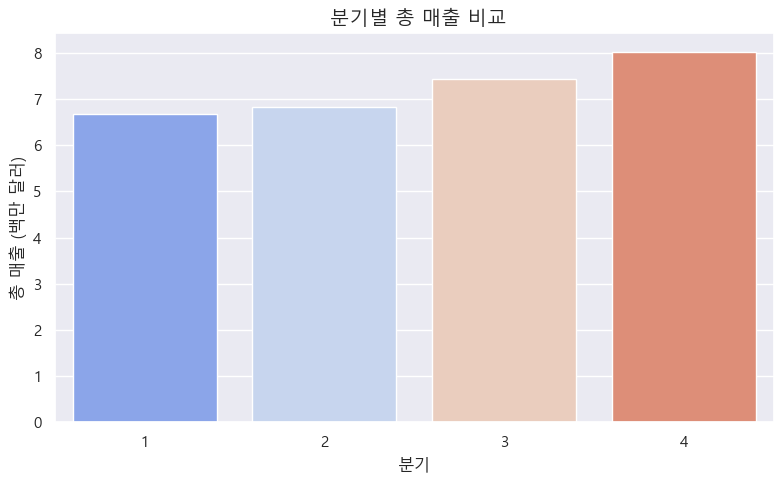

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font='Malgun Gothic', rc={'axes.unicode_minus': False})
plt.figure(figsize=(8,5))
sns.barplot(data=quarter_summary, x='분기', y='총 매출 (백만 $)', palette='coolwarm')
plt.title(' 분기별 총 매출 비교', fontsize=14)
plt.xlabel('분기')
plt.ylabel('총 매출 (백만 달러)')
plt.tight_layout()
plt.show()

In [121]:
# 분기 컬럼 생성
df['created_quarter'] = df['created_at'].dt.quarter

# 성별 + 분기별 평균 판매가 계산 (연도 무시)
gender_quarter_avg = (
    df.groupby(['product_department', 'created_quarter'])['product_retail_price']
    .mean()
    .reset_index()
    .rename(columns={'product_retail_price': 'avg_price'})
)

In [123]:
# 보기 편하게 pivot
pivot_avg = gender_quarter_avg.pivot(index='created_quarter', columns='product_department', values='avg_price')
pivot_avg.columns.name = None  # 컬럼명 정리
pivot_avg.index = ['Q1', 'Q2', 'Q3', 'Q4']  # 인덱스 이름 변경

# 소수점 2자리로 반올림 출력
print(pivot_avg.round(2))

      Men  Women
Q1  63.15  55.85
Q2  63.17  55.86
Q3  63.28  56.31
Q4  63.10  55.78


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\616470426.py:12: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\616470426.py:12: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129489 (\N{ADULT}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129309 (\N{HANDSHAKE}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


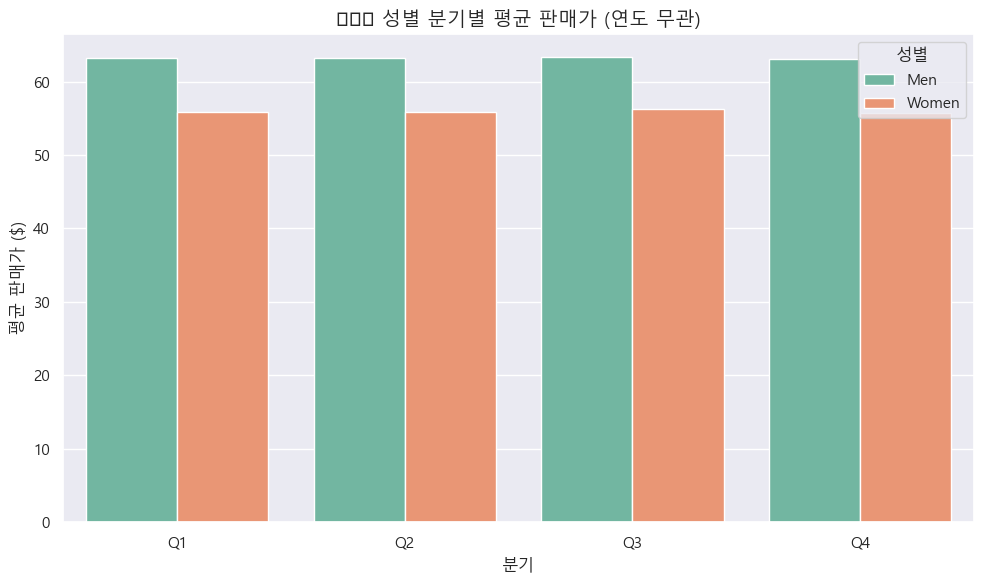

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=gender_quarter_avg, x='created_quarter', y='avg_price', hue='product_department', palette='Set2')

plt.title('🧑‍🤝‍🧑 성별 분기별 평균 판매가 (연도 무관)', fontsize=14)
plt.xlabel('분기')
plt.ylabel('평균 판매가 ($)')
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.legend(title='성별')
plt.tight_layout()
plt.show()

In [129]:
# created_at datetime 형 변환
df['created_at'] = pd.to_datetime(df['created_at'])

# 총 매출 컬럼 추가 (단위: 달러)
df['total_price'] = df['product_retail_price']

# 성별별 상위 제품 (매출 기준)
top_products_by_gender = (
    df.groupby(['product_department', 'product_name'])['total_price']
    .sum()
    .reset_index()
)

# 성별별로 나누고 정렬
top_men = top_products_by_gender[top_products_by_gender['product_department'] == 'Men'] \
    .sort_values(by='total_price', ascending=False) \
    .head(10)

top_women = top_products_by_gender[top_products_by_gender['product_department'] == 'Women'] \
    .sort_values(by='total_price', ascending=False) \
    .head(10)

# 단위 변환 (백만 달러)
top_men['total_price_million'] = top_men['total_price'] / 1e6
top_women['total_price_million'] = top_women['total_price'] / 1e6

# 컬럼 정리
top_men = top_men[['product_name', 'total_price_million']].reset_index(drop=True)
top_women = top_women[['product_name', 'total_price_million']].reset_index(drop=True)

# 출력
print(" 남성 제품 매출 TOP 10")
print(top_men)

print("\n 여성 제품 매출 TOP 10")
print(top_women)

 남성 제품 매출 TOP 10
                                        product_name  total_price_million
0  The North Face Apex Bionic Soft Shell Jacket -...             0.057792
1              Canada Goose Men's The Chateau Jacket             0.037490
2  The North Face Apex Bionic Mens Soft Shell Ski...             0.034314
3            True Religion Men's Ricky Straight Jean             0.027303
4      Diesel Men's Shioner Skinny Straight Leg Jean             0.024870
5  The North Face Nuptse 2 Jacket Deep Water Blue...             0.024381
6             Nike Jordan Retro 11 Bred Bootie Socks             0.024381
7         AIR JORDAN DOMINATE SHORTS MENS 465071-100             0.022575
8             Quiksilver Men's Rockefeller Walkshort             0.022575
9                                 Nobis Yatesy Parka             0.021850

 여성 제품 매출 TOP 10
                                        product_name  total_price_million
0  NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outst...             0.045150
1  

In [146]:
!pip install wordcloud

### product_name 워드클라우드

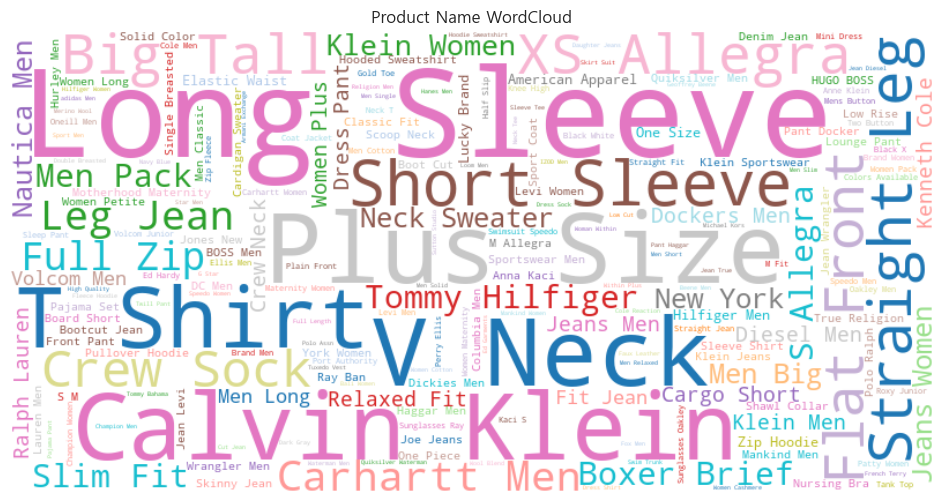

In [148]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# 데이터 불러오기 (경로는 상황에 맞게 수정)
df = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv')

# product_name 텍스트 전처리 (결측치 제거)
text = ' '.join(df['product_name'].dropna().astype(str))

# 워드클라우드 생성 (한글폰트 설정 필요하면 font_path 지정)
wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=200,
    colormap='tab20'
).generate(text)

# 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Product Name WordCloud')
plt.show()

### product_brand 워드 클라우드

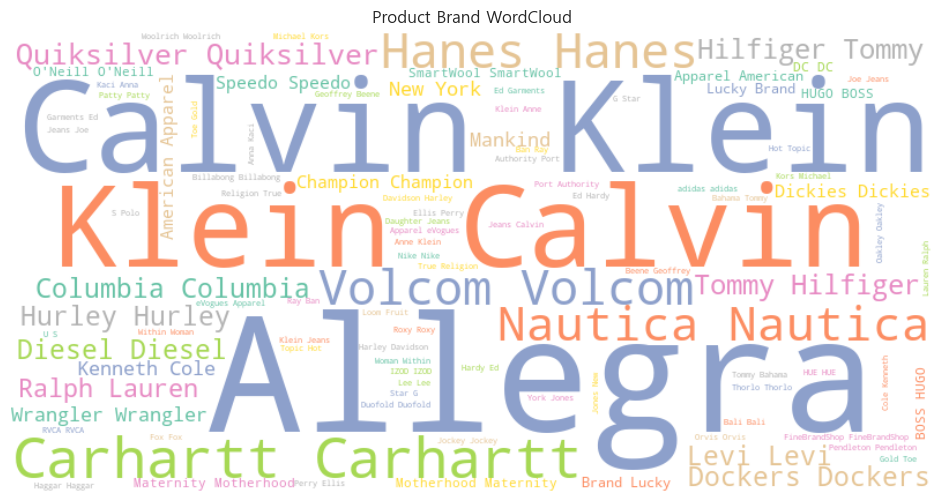

In [150]:
text_brand = ' '.join(df['product_brand'].dropna().astype(str))

wordcloud_brand = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='Set2'
).generate(text_brand)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_brand, interpolation='bilinear')
plt.axis('off')
plt.title('Product Brand WordCloud')
plt.show()

### 지역별 판매 특성 분석

#### 센터별 판매량, 평균 가격

In [155]:
# 센터별 판매량 (상품 수)
center_sales_count = df.groupby('product_distribution_center_id').size().reset_index(name='판매량')

# 센터별 평균 판매가격
center_avg_price = df.groupby('product_distribution_center_id')['product_retail_price'].mean().reset_index(name='평균가격')

# 두 개 합치기
center_summary = pd.merge(center_sales_count, center_avg_price, on='product_distribution_center_id')
print(center_summary)

   product_distribution_center_id    판매량       평균가격
0                               1  65116  58.653163
1                               2  64522  55.592453
2                               3  61218  69.552021
3                               4  46709  54.616572
4                               5  35803  61.962161
5                               6  43962  57.509563
6                               7  45377  63.919518
7                               8  50152  68.233434
8                               9  45577  39.463736
9                              10  32269  66.567946


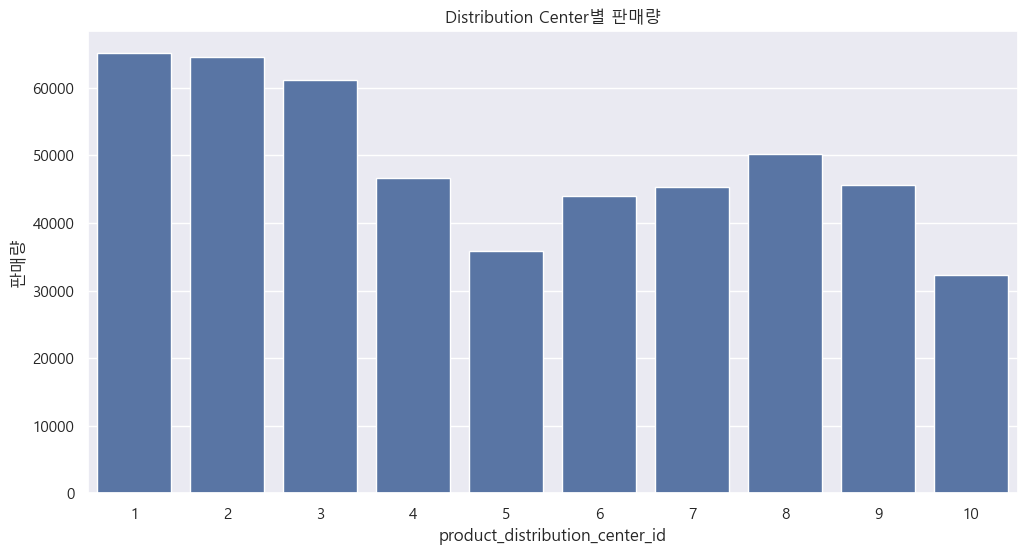

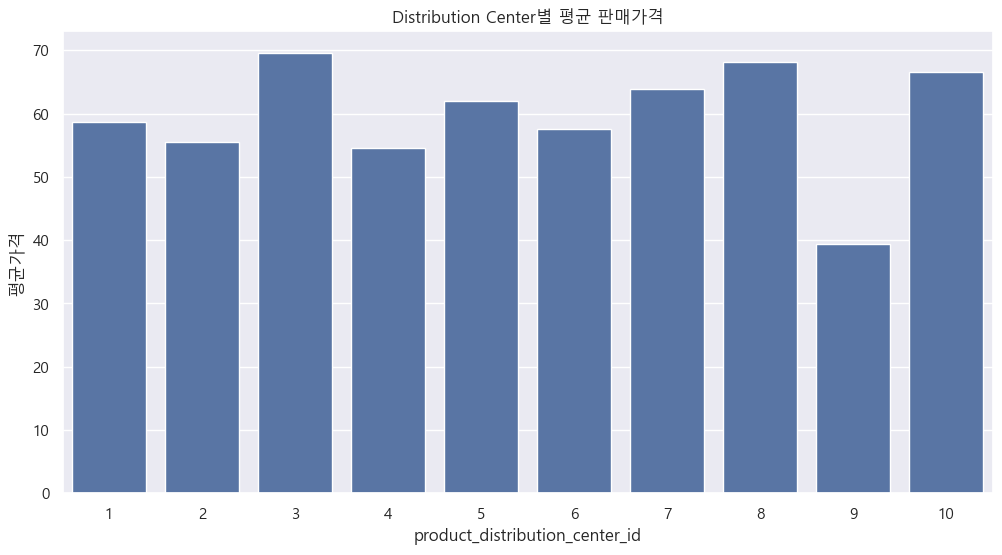

In [161]:
plt.figure(figsize=(12,6))
sns.barplot(data=center_summary, x='product_distribution_center_id', y='판매량')
plt.title('Distribution Center별 판매량')
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(data=center_summary, x='product_distribution_center_id', y='평균가격')
plt.title('Distribution Center별 평균 판매가격')
plt.show()

#### 센터 별 인기 카테고리 top3 뽑기

In [168]:
top3 = top_categories_per_center.groupby('product_distribution_center_id').apply(
    lambda x: x[['product_category', '판매량']].reset_index(drop=True)
)

rows = []

for center_id, group in top3.groupby(level=0):
    categories = group['product_category'].values
    sales = group['판매량'].values
    rows.append({
        '센터': center_id,
        '1위 카테고리': categories[0],
        '1위 판매량': sales[0],
        '2위 카테고리': categories[1] if len(categories) > 1 else None,
        '2위 판매량': sales[1] if len(sales) > 1 else None,
        '3위 카테고리': categories[2] if len(categories) > 2 else None,
        '3위 판매량': sales[2] if len(sales) > 2 else None,
    })

result = pd.DataFrame(rows)
print(result)

   센터                        1위 카테고리  1위 판매량            2위 카테고리  2위 판매량  \
0   1                    Tops & Tees    4922               Swim    4722   
1   2                      Intimates    7719     Sleep & Lounge    6069   
2   3                      Intimates    5758  Outerwear & Coats    5182   
3   4                           Swim    6113              Jeans    4465   
4   5                          Jeans    3158               Swim    3017   
5   6                    Tops & Tees    3760  Outerwear & Coats    3355   
6   7                          Jeans    5440     Sleep & Lounge    3463   
7   8                          Jeans    5810               Swim    4338   
8   9  Fashion Hoodies & Sweatshirts    4528          Intimates    4163   
9  10                      Underwear    4680              Jeans    3964   

                         3위 카테고리  3위 판매량  
0                 Sleep & Lounge    4440  
1                         Active    4733  
2                      Underwear    4945  
3 

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\2483043319.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3 = top_categories_per_center.groupby('product_distribution_center_id').apply(


### 판매량과 판매 평귱 가격으로 어느 지역이 매출 기여도가 높은지 알아봅시다

   product_distribution_center_id    판매량   평균가격  판매량_점수  평균가격_점수  종합_스코어
0                               3  61218  69.55   0.881    1.000   0.929
1                               1  65116  58.65   1.000    0.638   0.855
2                               2  64522  55.59   0.982    0.536   0.804
3                               8  50152  68.23   0.544    0.956   0.709
4                               7  45377  63.92   0.399    0.813   0.565
5                               4  46709  54.62   0.440    0.504   0.465
6                               6  43962  57.51   0.356    0.600   0.454
7                               5  35803  61.96   0.108    0.748   0.364
8                              10  32269  66.57   0.000    0.901   0.360
9                               9  45577  39.46   0.405    0.000   0.243


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8288\2547258888.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


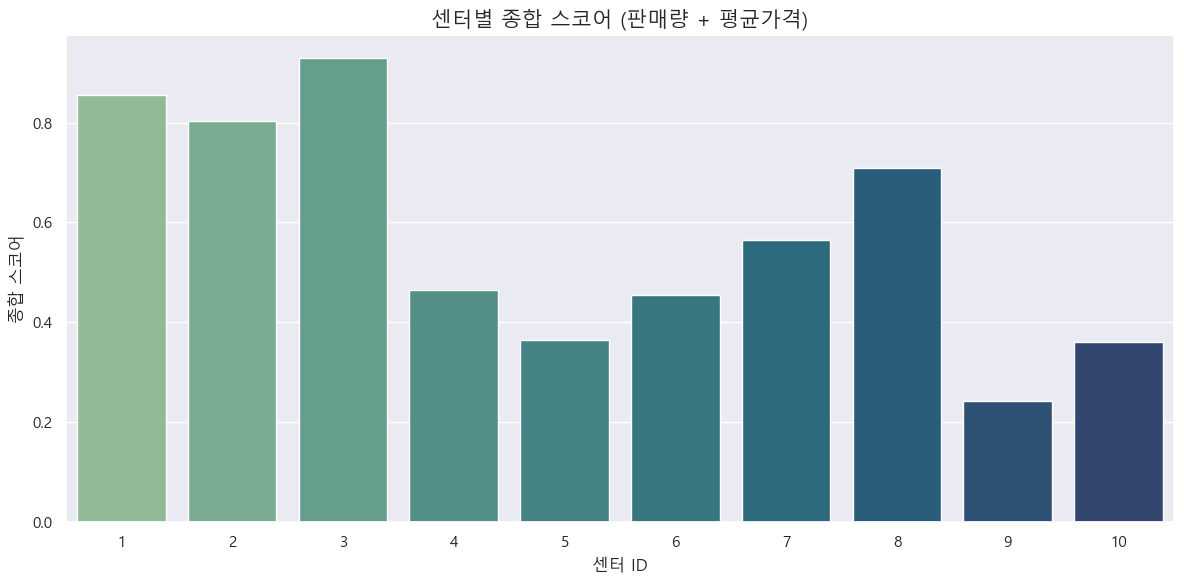

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 예시 데이터
df = pd.DataFrame({
    'product_distribution_center_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    '판매량': [65116, 64522, 61218, 46709, 35803, 43962, 45377, 50152, 45577, 32269],
    '평균가격': [58.65, 55.59, 69.55, 54.62, 61.96, 57.51, 63.92, 68.23, 39.46, 66.57]
})

#  Min-Max 정규화
df['판매량_점수'] = (df['판매량'] - df['판매량'].min()) / (df['판매량'].max() - df['판매량'].min())
df['평균가격_점수'] = (df['평균가격'] - df['평균가격'].min()) / (df['평균가격'].max() - df['평균가격'].min())

#  종합 스코어 계산 (가중치 적용: 판매량 0.6, 평균가격 0.4)
df['종합_스코어'] = df['판매량_점수'] * 0.6 + df['평균가격_점수'] * 0.4

#  정렬
df_sorted = df.sort_values('종합_스코어', ascending=False).reset_index(drop=True)

#  소수점 자르기 (가독성 향상)
df_sorted[['판매량_점수', '평균가격_점수', '종합_스코어']] = df_sorted[['판매량_점수', '평균가격_점수', '종합_스코어']].round(3)

#  출력
print(df_sorted[['product_distribution_center_id', '판매량', '평균가격', '판매량_점수', '평균가격_점수', '종합_스코어']])

#  시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    x='product_distribution_center_id',
    y='종합_스코어',
    data=df_sorted,
    palette='crest'
)
plt.title('센터별 종합 스코어 (판매량 + 평균가격)', fontsize=15)
plt.xlabel('센터 ID')
plt.ylabel('종합 스코어')
plt.tight_layout()
plt.show()